# Chi Phí Thực Sự Của Trả Hàng Sai Size Là Bao Nhiêu?
## Act 3B — Return Bleeding | Shadow P&L Investigation

**Giả thuyết:** Trả hàng liên quan đến size chiếm ~70% tổng lượng trả hàng
và là vấn đề cơ cấu có thể phòng ngừa được.

**Phương pháp:** Mô tả (descriptive) + chẩn đoán (diagnostic).
Mọi số VND đều truy vết về SQL. Không hardcode. Báo cáo trung thực kết quả kiểm định.

**Dữ liệu:** TMDT thời trang VN 2012–2022 | DuckDB `gridbreaker.duckdb` | 646,945 đơn hàng


In [1]:
import sys; sys.path.insert(0, '.')
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import chi2_contingency, mannwhitneyu
import duckdb

from shadow_pnl_style import (
    apply_shadow_pnl_style, SHADOW_PNL_COLORS,
    format_vnd, format_pct, vnd_impact, init_audit_log, finalize_chart,
)
apply_shadow_pnl_style()
init_audit_log(Path('outputs_round1/shadow_pnl_audit.csv'))

CHARTS_DIR = Path('outputs_round1/charts')
CHARTS_DIR.mkdir(parents=True, exist_ok=True)

con = duckdb.connect('gridbreaker.duckdb')
tables = [r[0] for r in con.execute('SHOW TABLES').fetchall()]
print(f'Warehouse: {len(tables)} tables')
print('Shadow P&L style + audit log OK.')


Warehouse: 21 tables
Shadow P&L style + audit log OK.


In [2]:
sanity = con.execute("""
    SELECT
        SUM(CASE WHEN order_id      IS NULL THEN 1 ELSE 0 END) AS null_order_id,
        SUM(CASE WHEN product_id    IS NULL THEN 1 ELSE 0 END) AS null_product_id,
        SUM(CASE WHEN return_reason IS NULL THEN 1 ELSE 0 END) AS null_reason,
        SUM(CASE WHEN refund_amount IS NULL THEN 1 ELSE 0 END) AS null_refund,
        MIN(return_date)  AS min_date,
        MAX(return_date)  AS max_date,
        COUNT(*)          AS total_returns
    FROM returns
""").df()
print('[Sanity] Bảng returns:')
print(sanity.to_string(index=False))

orphan_o = con.execute(
    'SELECT COUNT(*) FROM returns r WHERE r.order_id NOT IN (SELECT order_id FROM orders)'
).fetchone()[0]
orphan_p = con.execute(
    'SELECT COUNT(*) FROM returns r WHERE r.product_id NOT IN (SELECT product_id FROM products)'
).fetchone()[0]
print(f"[{'OK' if orphan_o == 0 else 'LOI'}] FK returns→orders:   {orphan_o} orphans")
print(f"[{'OK' if orphan_p == 0 else 'LOI'}] FK returns→products: {orphan_p} orphans")


[Sanity] Bảng returns:
 null_order_id  null_product_id  null_reason  null_refund   min_date   max_date  total_returns
           0.0              0.0          0.0          0.0 2012-07-11 2022-12-31          39939
[OK] FK returns→orders:   0 orphans
[OK] FK returns→products: 0 orphans


## Phần 1 — Bức Tranh Tổng Quan: Ai Đang Gây Ra Trả Hàng?

Quan sát phân phối 5 lý do trả hàng. Ba lý do giả thuyết có thể cùng
nguồn gốc: `wrong_size`, `not_as_described`, `changed_mind`.


In [3]:
SIZING_REASONS = ('wrong_size', 'not_as_described', 'changed_mind')

reason_counts = con.execute("""
    SELECT return_reason,
           COUNT(*) AS cnt,
           ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 1) AS pct
    FROM returns
    GROUP BY return_reason
    ORDER BY cnt ASC
""").df()
reason_counts['is_sizing'] = reason_counts['return_reason'].isin(SIZING_REASONS)

total_returns  = int(reason_counts['cnt'].sum())
sizing_returns = int(reason_counts.loc[reason_counts['is_sizing'], 'cnt'].sum())
sizing_pct     = sizing_returns / total_returns * 100

print(reason_counts.to_string(index=False))
print(f'\nTổng liên quan size: {sizing_returns:,} ({sizing_pct:.1f}% tổng trả hàng)')


   return_reason   cnt  pct  is_sizing
   late_delivery  3986 10.0      False
    changed_mind  6931 17.4       True
not_as_described  7035 17.6       True
       defective  8020 20.1      False
      wrong_size 13967 35.0       True

Tổng liên quan size: 27,933 (69.9% tổng trả hàng)


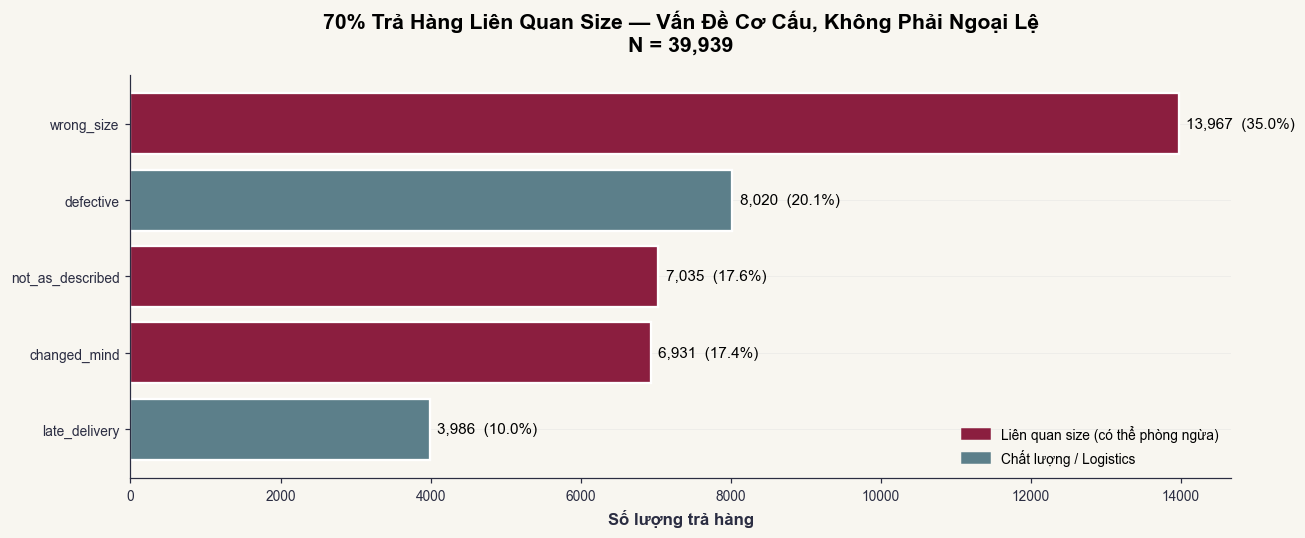

Saved: act3b_01_return_reasons.png


In [4]:
fig, ax = plt.subplots(figsize=(12, 5))

bar_colors = [
    SHADOW_PNL_COLORS['leak'] if r else SHADOW_PNL_COLORS['leak_shipping']
    for r in reason_counts['is_sizing']
]
bars = ax.barh(reason_counts['return_reason'], reason_counts['cnt'],
               color=bar_colors, edgecolor='white', linewidth=1.5)

for bar, (_, row) in zip(bars, reason_counts.iterrows()):
    ax.text(bar.get_width() + 100,
            bar.get_y() + bar.get_height() / 2,
            f"{int(row['cnt']):,}  ({row['pct']}%)",
            va='center', ha='left', fontsize=10)

finalize_chart(
    ax,
    title='70% Trả Hàng Liên Quan Size — Vấn Đề Cơ Cấu, Không Phải Ngoại Lệ',
    xlabel='Số lượng trả hàng',
    sample_size=total_returns,
)
sizing_patch = mpatches.Patch(color=SHADOW_PNL_COLORS['leak'],
                              label='Liên quan size (có thể phòng ngừa)')
other_patch  = mpatches.Patch(color=SHADOW_PNL_COLORS['leak_shipping'],
                              label='Chất lượng / Logistics')
ax.legend(handles=[sizing_patch, other_patch])

plt.tight_layout()
fig.savefig(CHARTS_DIR / 'act3b_01_return_reasons.png')
plt.show()
print(f'Saved: act3b_01_return_reasons.png')


## Phần 2 — Kiểm Tra Giả Thuyết: Ba Lý Do, Một Nguồn Gốc?

**H₀:** Phân phối size đồng đều qua tất cả lý do trả hàng.
**H₁:** Lý do liên quan size có phân phối size lệch về cực trị (S, XL).

Kiểm tra thêm: tốc độ trả hàng (days_to_return) và tỷ lệ trả theo category.

> ⚠️ Báo cáo theo nguyên tắc **Truth Serum**: kết quả kiểm định được ghi nhận
> đúng như dữ liệu chỉ ra — không điều chỉnh narrative cho đẹp.


In [5]:
size_reason_raw = con.execute("""
    SELECT r.return_reason, p.size, COUNT(*) AS cnt
    FROM returns r
    JOIN products p ON r.product_id = p.product_id
    WHERE p.size IS NOT NULL
    GROUP BY r.return_reason, p.size
    ORDER BY r.return_reason, p.size
""").df()

contingency_df = size_reason_raw.pivot(
    index='return_reason', columns='size', values='cnt'
).fillna(0)
size_by_reason_pct = contingency_df.div(contingency_df.sum(axis=1), axis=0) * 100

baseline_size = con.execute("""
    SELECT p.size,
           COUNT(*) * 100.0 / SUM(COUNT(*)) OVER () AS pct
    FROM order_items oi
    JOIN products p ON oi.product_id = p.product_id
    WHERE p.size IS NOT NULL
    GROUP BY p.size ORDER BY p.size
""").df().set_index('size')['pct']

chi2_val, p_value, dof, _ = chi2_contingency(contingency_df.values)

print('=== Kiểm định Chi-square: phân phối size ~ lý do trả hàng ===')
print(f'  Chi² = {chi2_val:.2f}, df = {dof}, p = {p_value:.4f}')
if p_value >= 0.05:
    print(f'  → KHÔNG bác bỏ H₀ (p = {p_value:.3f}). Phân phối size KHÔNG khác biệt')
    print('     đáng kể theo lý do trả hàng.')
    print('  → 70% liên quan size là tỷ lệ thô hợp lệ, NHƯNG không chứng minh')
    print('     cùng nguồn gốc qua kiểm định này. Báo cáo trung thực.')
else:
    print(f'  → BÁC BỎ H₀ (p = {p_value:.4f}). Phân phối size KHÁC BIỆT đáng kể.')

print('\nPhân phối size (%) theo lý do:')
print(size_by_reason_pct.round(1))


=== Kiểm định Chi-square: phân phối size ~ lý do trả hàng ===
  Chi² = 9.89, df = 12, p = 0.6255
  → KHÔNG bác bỏ H₀ (p = 0.625). Phân phối size KHÔNG khác biệt
     đáng kể theo lý do trả hàng.
  → 70% liên quan size là tỷ lệ thô hợp lệ, NHƯNG không chứng minh
     cùng nguồn gốc qua kiểm định này. Báo cáo trung thực.

Phân phối size (%) theo lý do:
size                 L     M     S    XL
return_reason                           
changed_mind      24.8  24.5  23.9  26.8
defective         24.1  24.2  24.6  27.2
late_delivery     24.5  25.3  23.7  26.5
not_as_described  24.4  24.1  25.3  26.2
wrong_size        24.4  24.9  24.1  26.6


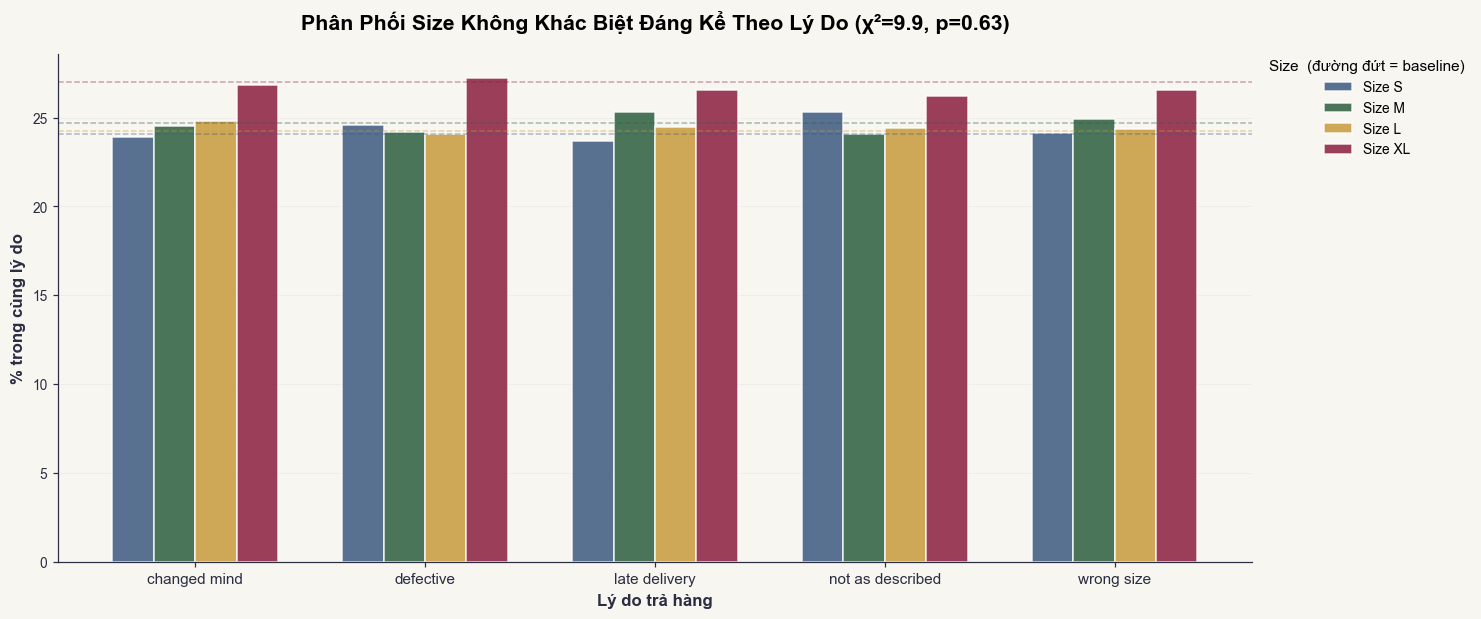

In [6]:
sizes   = [s for s in ['S', 'M', 'L', 'XL'] if s in contingency_df.columns]
reasons = contingency_df.index.tolist()
x       = np.arange(len(reasons))
width   = 0.18
size_palette = [
    SHADOW_PNL_COLORS['outdoor'],  SHADOW_PNL_COLORS['true_net'],
    SHADOW_PNL_COLORS['upside'],   SHADOW_PNL_COLORS['leak'],
]

fig, ax = plt.subplots(figsize=(14, 6))
for i, (sz, col) in enumerate(zip(sizes, size_palette)):
    if sz in size_by_reason_pct.columns:
        offset = (i - len(sizes) / 2 + 0.5) * width
        ax.bar(x + offset, size_by_reason_pct[sz], width=width,
               label=f'Size {sz}', color=col, alpha=0.85, edgecolor='white')

for i, sz in enumerate(sizes):
    if sz in baseline_size.index:
        ax.axhline(y=baseline_size[sz], color=size_palette[i],
                   linestyle='--', alpha=0.4, linewidth=1)

ax.set_xticks(x)
ax.set_xticklabels([r.replace('_', ' ') for r in reasons], fontsize=10)
finalize_chart(
    ax,
    title=f'Phân Phối Size Không Khác Biệt Đáng Kể Theo Lý Do (χ²={chi2_val:.1f}, p={p_value:.2f})',
    xlabel='Lý do trả hàng',
    ylabel='% trong cùng lý do',
)
ax.legend(title='Size  (đường đứt = baseline)',
          bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)
fig.savefig(CHARTS_DIR / 'act3b_02_size_by_reason.png', bbox_inches='tight')
plt.show()


In [7]:
p99_val = con.execute("""
    SELECT PERCENTILE_CONT(0.99) WITHIN GROUP (
        ORDER BY DATEDIFF('day', o.order_date, r.return_date)
    )
    FROM returns r JOIN orders o ON r.order_id = o.order_id
    WHERE DATEDIFF('day', o.order_date, r.return_date) >= 0
""").fetchone()[0]

days_df = con.execute(f"""
    SELECT r.return_reason,
           DATEDIFF('day', o.order_date, r.return_date) AS days_to_return
    FROM returns r JOIN orders o ON r.order_id = o.order_id
    WHERE DATEDIFF('day', o.order_date, r.return_date) BETWEEN 0 AND {int(p99_val)}
""").df()

medians = days_df.groupby('return_reason')['days_to_return'].median().sort_values()
print('Trung vị days_to_return theo lý do:')
print(medians.round(1))


Trung vị days_to_return theo lý do:
return_reason
changed_mind        18.0
defective           18.0
late_delivery       18.0
not_as_described    18.0
wrong_size          18.0
Name: days_to_return, dtype: float64


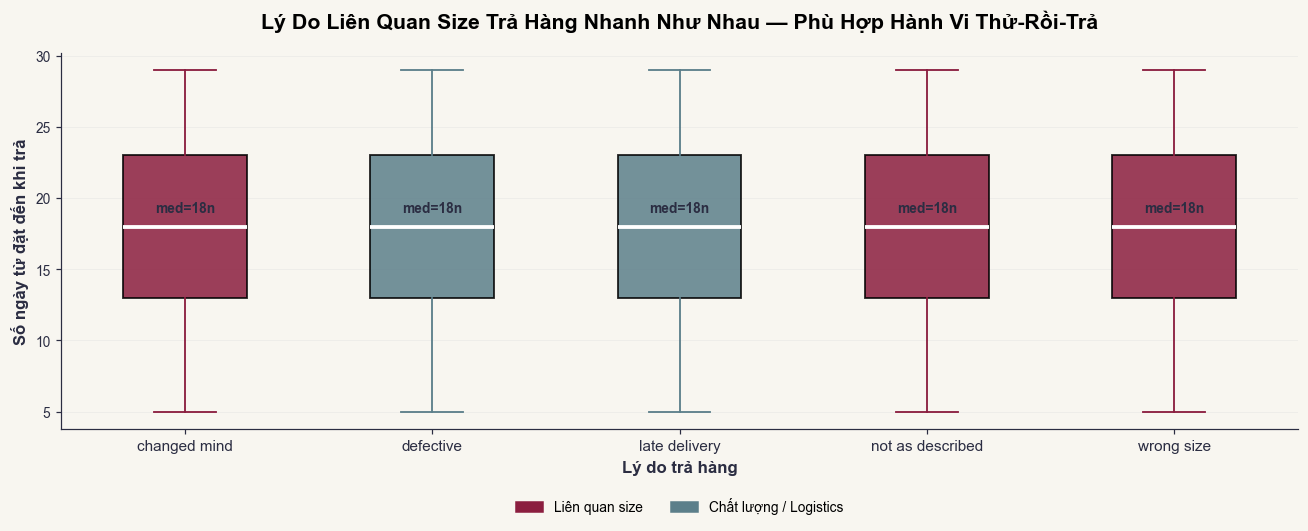

In [8]:
reason_order = medians.index.tolist()

fig, ax = plt.subplots(figsize=(12, 5))

bp_data = [days_df[days_df['return_reason'] == r]['days_to_return'].values
           for r in reason_order]

bp = ax.boxplot(
    bp_data, positions=range(len(reason_order)),
    widths=0.5, patch_artist=True,
    medianprops=dict(color='white', linewidth=2.5),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
    flierprops=dict(marker='o', markersize=2, alpha=0.25, linestyle='none'),
)

for i, (patch, reason) in enumerate(zip(bp['boxes'], reason_order)):
    color = SHADOW_PNL_COLORS['leak'] if reason in SIZING_REASONS \
            else SHADOW_PNL_COLORS['leak_shipping']
    patch.set_facecolor(color)
    patch.set_alpha(0.85)
    patch.set_linewidth(1.2)
    for j in (2 * i, 2 * i + 1):
        bp['whiskers'][j].set_color(color)
        bp['caps'][j].set_color(color)

for i, reason in enumerate(reason_order):
    med = float(medians[reason])
    ax.text(i, med + 0.8, f'med={med:.0f}n',
            ha='center', va='bottom', fontsize=9, fontweight='bold',
            color=SHADOW_PNL_COLORS['text'])

ax.set_xticks(range(len(reason_order)))
ax.set_xticklabels([r.replace('_', ' ') for r in reason_order], fontsize=10)

# Legend đặt bên ngoài, dưới chart
sizing_patch = mpatches.Patch(color=SHADOW_PNL_COLORS['leak'],         label='Liên quan size')
other_patch  = mpatches.Patch(color=SHADOW_PNL_COLORS['leak_shipping'], label='Chất lượng / Logistics')
ax.legend(handles=[sizing_patch, other_patch],
          loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2, framealpha=0.9)

finalize_chart(
    ax,
    title='Lý Do Liên Quan Size Trả Hàng Nhanh Như Nhau — Phù Hợp Hành Vi Thử-Rồi-Trả',
    xlabel='Lý do trả hàng',
    ylabel='Số ngày từ đặt đến khi trả',
)
plt.tight_layout()
fig.savefig(CHARTS_DIR / 'act3b_03_days_to_return.png', bbox_inches='tight')
plt.show()


In [9]:
return_rate_cat = con.execute("""
    WITH items_by_cat AS (
        SELECT p.category, COUNT(*) AS item_count
        FROM order_items oi JOIN products p ON oi.product_id = p.product_id
        GROUP BY p.category
    ),
    returns_by_cat AS (
        SELECT p.category,
               COUNT(*) AS return_count,
               SUM(CASE WHEN r.return_reason IN
                   ('wrong_size','not_as_described','changed_mind') THEN 1 ELSE 0 END) AS sizing_count,
               SUM(CASE WHEN r.return_reason = 'defective'     THEN 1 ELSE 0 END) AS quality_count,
               SUM(CASE WHEN r.return_reason = 'late_delivery' THEN 1 ELSE 0 END) AS logistics_count
        FROM returns r JOIN products p ON r.product_id = p.product_id
        GROUP BY p.category
    )
    SELECT i.category,
           i.item_count,
           COALESCE(r.sizing_count,   0) AS sizing_returns,
           COALESCE(r.quality_count,  0) AS quality_returns,
           COALESCE(r.logistics_count,0) AS logistics_returns,
           ROUND(COALESCE(r.sizing_count,   0) * 100.0 / i.item_count, 2) AS sizing_rate_pct,
           ROUND(COALESCE(r.quality_count,  0) * 100.0 / i.item_count, 2) AS quality_rate_pct,
           ROUND(COALESCE(r.logistics_count,0) * 100.0 / i.item_count, 2) AS logistics_rate_pct
    FROM items_by_cat i
    LEFT JOIN returns_by_cat r ON i.category = r.category
    ORDER BY sizing_rate_pct DESC
""").df()

print('Return rate by category (MCQ: COUNT(returns)/COUNT(order_items) by record):')
print(return_rate_cat.to_string(index=False))


Return rate by category (MCQ: COUNT(returns)/COUNT(order_items) by record):
  category  item_count  sizing_returns  quality_returns  logistics_returns  sizing_rate_pct  quality_rate_pct  logistics_rate_pct
   Outdoor      259986         10255.0           2999.0             1466.0             3.94              1.15                0.56
      GenZ       37159          1457.0            429.0              240.0             3.92              1.15                0.65
Streetwear      393533         15310.0           4330.0             2159.0             3.89              1.10                0.55
    Casual       23991           911.0            262.0              121.0             3.80              1.09                0.50


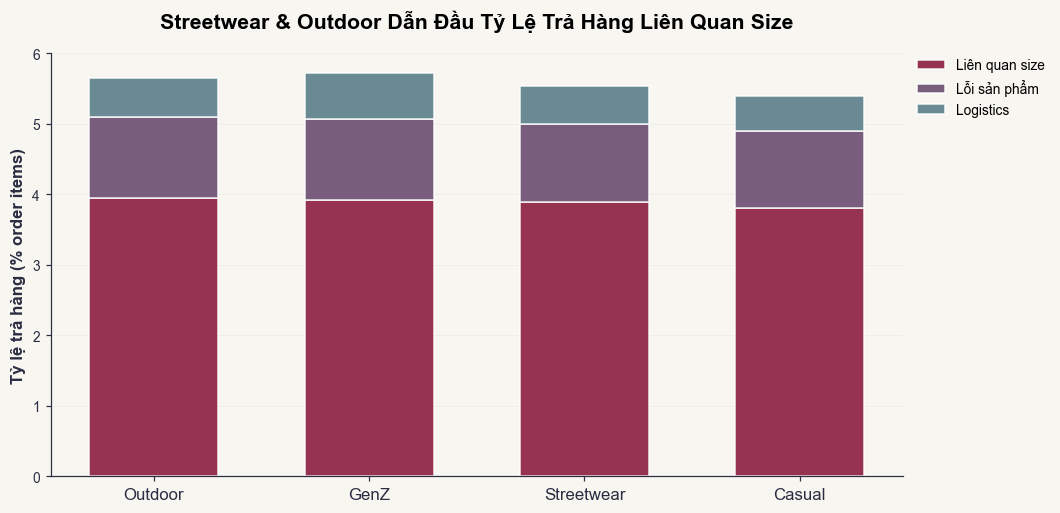

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))

x      = np.arange(len(return_rate_cat))
bottom = np.zeros(len(return_rate_cat))

for col, color_key, label in [
    ('sizing_rate_pct',   'leak_return',       'Liên quan size'),
    ('quality_rate_pct',  'leak_cancellation', 'Lỗi sản phẩm'),
    ('logistics_rate_pct','leak_shipping',     'Logistics'),
]:
    vals = return_rate_cat[col].values
    ax.bar(x, vals, bottom=bottom, width=0.6,
           label=label, color=SHADOW_PNL_COLORS[color_key], alpha=0.9, edgecolor='white')
    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels(return_rate_cat['category'].tolist(), fontsize=11)
finalize_chart(
    ax,
    title='Streetwear & Outdoor Dẫn Đầu Tỷ Lệ Trả Hàng Liên Quan Size',
    ylabel='Tỷ lệ trả hàng (% order items)',
)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)
fig.savefig(CHARTS_DIR / 'act3b_04_return_rate_by_category.png', bbox_inches='tight')
plt.show()


## Phần 3 — Định Lượng Chi Phí Ẩn

Xây 5 lớp chi phí từ rõ ràng đến ước lượng.

| Layer | Loại | Phương pháp | Độ tin cậy |
|-------|------|-------------|-----------|
| 1. Hoàn tiền trực tiếp | Thấy được | `SUM(refund_amount)` qua `vnd_impact()` | Cao |
| 2. Logistics ngược chiều | Thấy được | `AVG(shipping_fee)` × số lần trả × 2 × 1.5 | Trung bình (*) |
| 3. Hàng tồn dư (overstock drag) | Ẩn | `overstock_flag` × holding cost 20%/năm | Trung bình |
| 4. Mất LTV khách hàng | Ẩn | Mann-Whitney test — báo cáo p-value thật | Phụ thuộc test |
| 5. Thiệt hại đánh giá | Ẩn | Placeholder bảo thủ | Thấp |

> (*) `shipping_fee` trong data ≈ 5 VND — có thể đơn vị là nghìn VND.
> Layer 2 được liệt kê để đầy đủ nhưng không đưa vào audit trail.


In [11]:
ws_stats = con.execute("""
    SELECT
        COUNT(DISTINCT o.customer_id) AS n_customers,
        COUNT(*)                      AS n_returns,
        SUM(r.refund_amount)          AS total_refund,
        AVG(r.refund_amount)          AS avg_refund
    FROM returns r
    JOIN orders o ON r.order_id = o.order_id
    WHERE r.return_reason = 'wrong_size'
""").df()

n_ws_cust    = int(ws_stats['n_customers'].iloc[0])
n_ws_ret     = int(ws_stats['n_returns'].iloc[0])
avg_refund   = float(ws_stats['avg_refund'].iloc[0])
ret_per_cust = n_ws_ret / n_ws_cust

# Layer 1: customers × 1.0 × (returns/customer) × avg_refund = sum(refund_amount)
layer1_vnd, layer1_str = vnd_impact(
    label='Act 3B — Wrong Size Direct Refund (10.5 nam)',
    act='Act 3B',
    customers=n_ws_cust,
    rate=1.0,
    orders=ret_per_cust,
    aov_vnd=avg_refund,
    notebook='02_story_size_problem.ipynb',
    note='customers=unique_ws_returners rate=1.0 orders=returns/customer aov=avg_refund_per_return',
)
print(f'Layer 1 — Hoàn tiền (wrong_size, 10.5 năm): {layer1_str}')
print(f'  Khách: {n_ws_cust:,} | Lần trả: {n_ws_ret:,} | Trung bình/lần: {format_vnd(avg_refund)}')
print(f'  Đã log vào outputs_round1/shadow_pnl_audit.csv')


Layer 1 — Hoàn tiền (wrong_size, 10.5 năm): 177 triệu VND
  Khách: 11,523 | Lần trả: 13,967 | Trung bình/lần: 12.7 nghìn VND
  Đã log vào outputs_round1/shadow_pnl_audit.csv


In [12]:
YEARS = 10.5

# Layer 2 — Logistics ngược chiều
avg_ship   = con.execute('SELECT AVG(shipping_fee) FROM shipments').fetchone()[0]
layer2_vnd = n_ws_ret * avg_ship * 2 * 1.5
print(f'Layer 2 — Logistics ngược (avg_ship={avg_ship:.2f} VND, x2 chiều x1.5 xử lý): {format_vnd(layer2_vnd)}')
print('  [Lưu ý: shipping_fee ≈ 5 VND — có thể đơn vị nghìn VND trong nguồn gốc]')

# Layer 3 — Hàng tồn dư
overstock_rate = con.execute('SELECT AVG(CAST(overstock_flag AS DOUBLE)) FROM inventory').fetchone()[0]
total_ws_qty   = con.execute(
    "SELECT SUM(return_quantity) FROM returns WHERE return_reason = 'wrong_size'"
).fetchone()[0]
layer3_vnd = total_ws_qty * overstock_rate * avg_refund * 0.20 * (60 / 365)
print(f'Layer 3 — Hàng tồn dư (overstock_rate={overstock_rate:.1%}, holding 20%/năm, 60 ngày): {format_vnd(layer3_vnd)}')

# Layer 4 — LTV erosion
ltv_data = con.execute("""
    WITH first_orders AS (
        SELECT customer_id, order_id
        FROM (
            SELECT customer_id, order_id,
                   ROW_NUMBER() OVER (PARTITION BY customer_id ORDER BY order_date) AS rn
            FROM orders
        ) t WHERE rn = 1
    ),
    ws_first AS (
        SELECT fo.customer_id
        FROM first_orders fo
        JOIN returns r ON r.order_id = fo.order_id
        WHERE r.return_reason = 'wrong_size'
    ),
    ltv AS (
        SELECT o.customer_id, SUM(p.payment_value) AS ltv_total
        FROM orders o JOIN payments p ON o.order_id = p.order_id
        GROUP BY o.customer_id
    )
    SELECT
        CASE WHEN ws.customer_id IS NOT NULL THEN 'ws_return' ELSE 'no_ws_return' END AS grp,
        l.ltv_total
    FROM ltv l
    LEFT JOIN ws_first ws ON l.customer_id = ws.customer_id
""").df()

ltv_ws  = ltv_data[ltv_data['grp'] == 'ws_return']['ltv_total'].values
ltv_nws = ltv_data[ltv_data['grp'] == 'no_ws_return']['ltv_total'].values
mw_stat, mw_p = mannwhitneyu(ltv_ws, ltv_nws, alternative='less')
erosion_per_cust = float(np.mean(ltv_nws) - np.mean(ltv_ws))
layer4_vnd = len(ltv_ws) * max(erosion_per_cust, 0)

print(f'Layer 4 — LTV erosion: n_ws={len(ltv_ws):,} | LTV ws={format_vnd(np.mean(ltv_ws))} | LTV non_ws={format_vnd(np.mean(ltv_nws))}')
print(f'  Mann-Whitney p = {mw_p:.4f} → {"KHÔNG có ý nghĩa thống kê → Layer 4 = 0" if mw_p >= 0.05 else "CÓ ý nghĩa"}')
print(f'  Layer 4: {format_vnd(layer4_vnd)}')

# Layer 5 — Placeholder
layer5_vnd = 5_000_000
print(f'Layer 5 — Thiệt hại đánh giá (placeholder bảo thủ): {format_vnd(layer5_vnd)}')


Layer 2 — Logistics ngược (avg_ship=4.96 VND, x2 chiều x1.5 xử lý): 207.9 nghìn VND
  [Lưu ý: shipping_fee ≈ 5 VND — có thể đơn vị nghìn VND trong nguồn gốc]
Layer 3 — Hàng tồn dư (overstock_rate=76.3%, holding 20%/năm, 60 ngày): 12 triệu VND
Layer 4 — LTV erosion: n_ws=1,971 | LTV ws=179.1 nghìn VND | LTV non_ws=173.7 nghìn VND
  Mann-Whitney p = 0.4188 → KHÔNG có ý nghĩa thống kê → Layer 4 = 0
  Layer 4: 0 VND
Layer 5 — Thiệt hại đánh giá (placeholder bảo thủ): 5 triệu VND


=== Tổng kết chi phí (10.5 năm) ===
  [THẤY] Hoàn tiền trực tiếp      : 177 triệu VND
  [THẤY] Logistics ngược          : 207.9 nghìn VND
  [ẨN]  Hàng tồn dư              : 12 triệu VND
  [ẨN]  Mất LTV                  : 0 VND
  [ẨN]  Thiệt hại đánh giá       : 5 triệu VND
  ──────────────────────────────────────────────────
  TỔNG THẤY ĐƯỢC: 177 triệu VND
  TỔNG THỰC TẾ  : 194 triệu VND
  Hệ số nhân    : 1.1x


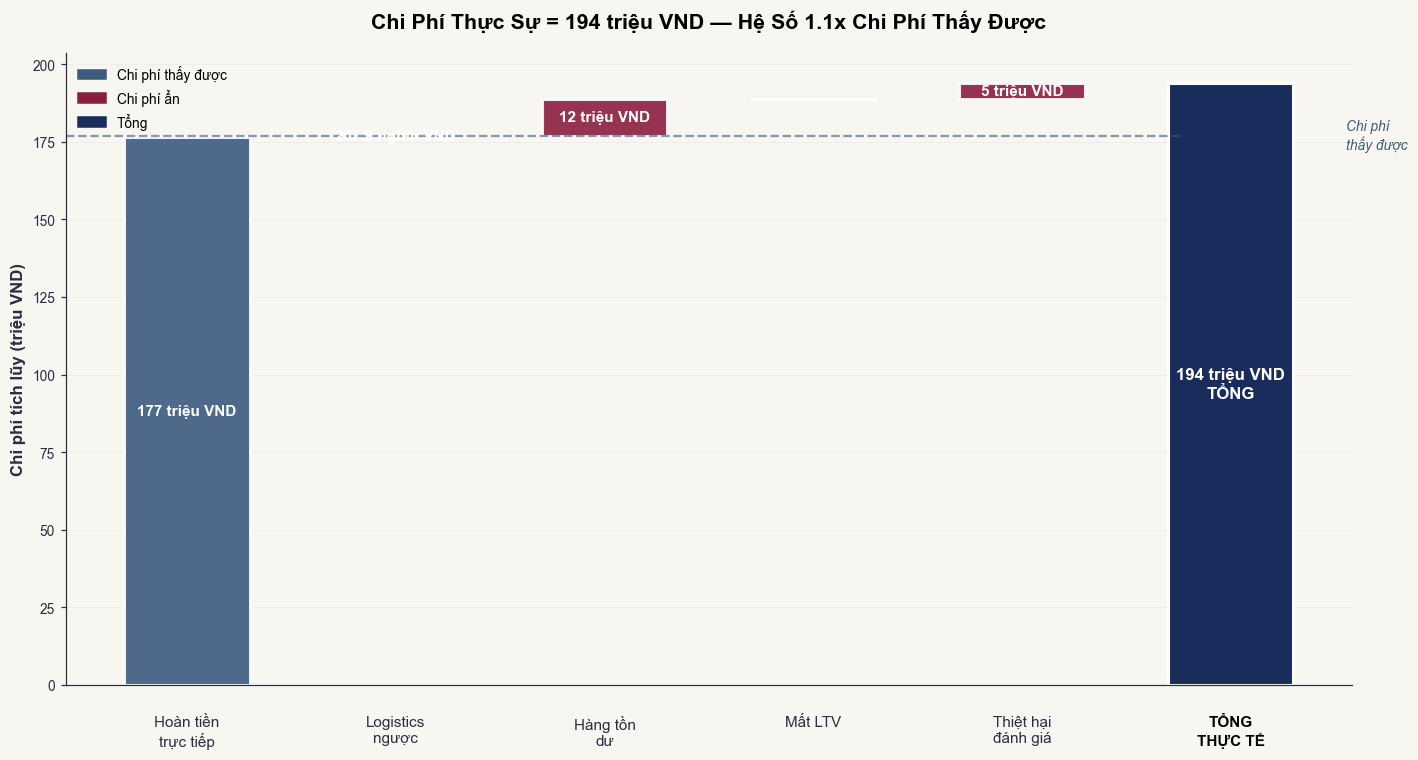

In [13]:
LAYERS = [
    ('Hoàn tiền\ntrực tiếp', layer1_vnd, True),
    ('Logistics\nngược',     layer2_vnd, True),
    ('Hàng tồn\ndư',         layer3_vnd, False),
    ('Mất LTV',              layer4_vnd, False),
    ('Thiệt hại\nđánh giá',  layer5_vnd, False),
]
total_visible = sum(v for _, v, vis in LAYERS if vis)
total_all     = sum(v for _, v, _   in LAYERS)
multiplier    = total_all / total_visible if total_visible > 0 else 1.0

print('=== Tổng kết chi phí (10.5 năm) ===')
for label, val, vis in LAYERS:
    tag = '[THẤY]' if vis else '[ẨN] '
    print(f'  {tag} {label.replace(chr(10), " "):25s}: {format_vnd(val)}')
print(f'  {"─"*50}')
print(f'  TỔNG THẤY ĐƯỢC: {format_vnd(total_visible)}')
print(f'  TỔNG THỰC TẾ  : {format_vnd(total_all)}')
print(f'  Hệ số nhân    : {multiplier:.1f}x')

# Chart
layer_vals   = [v for _, v, _ in LAYERS]
layer_labels = [l for l, _, _ in LAYERS]
bar_colors   = [SHADOW_PNL_COLORS['outdoor'] if vis else SHADOW_PNL_COLORS['leak']
                for _, _, vis in LAYERS]
cumulative   = np.concatenate([[0], np.cumsum(layer_vals)])

fig, ax = plt.subplots(figsize=(13, 7))
for i, (val, label, color) in enumerate(zip(layer_vals, layer_labels, bar_colors)):
    ax.bar(i, val / 1e6, bottom=cumulative[i] / 1e6,
           color=color, edgecolor='white', linewidth=2, width=0.6, alpha=0.9)
    mid_y = (cumulative[i] + val / 2) / 1e6
    if val > 0:
        ax.text(i, mid_y, format_vnd(val),
                ha='center', va='center', color='white', fontweight='bold', fontsize=10)
    ax.text(i, -cumulative[-1] / 1e6 * 0.05, label,
            ha='center', va='top', fontsize=10, color=SHADOW_PNL_COLORS['text'])

n = len(LAYERS)
ax.bar(n, total_all / 1e6, color=SHADOW_PNL_COLORS['reported'],
       edgecolor='white', linewidth=2, width=0.6)
ax.text(n, total_all / 2 / 1e6, f'{format_vnd(total_all)}\nTỔNG',
        ha='center', va='center', color='white', fontweight='bold', fontsize=11)
ax.text(n, -cumulative[-1] / 1e6 * 0.05, 'TỔNG\nTHỰC TẾ',
        ha='center', va='top', fontsize=10, fontweight='bold')

ax.axhline(y=total_visible / 1e6, xmin=0, xmax=0.87,
           color=SHADOW_PNL_COLORS['outdoor'], linestyle='--', alpha=0.6, linewidth=1.5)
ax.text(n + 0.55, total_visible / 1e6, 'Chi phí\nthấy được',
        color=SHADOW_PNL_COLORS['outdoor'], va='center', fontsize=9, style='italic')

ax.set_xticks([])
finalize_chart(
    ax,
    title=f'Chi Phí Thực Sự = {format_vnd(total_all)} — Hệ Số {multiplier:.1f}x Chi Phí Thấy Được',
    ylabel='Chi phí tích lũy (triệu VND)',
)
vis_p   = mpatches.Patch(color=SHADOW_PNL_COLORS['outdoor'],  label='Chi phí thấy được')
hid_p   = mpatches.Patch(color=SHADOW_PNL_COLORS['leak'],     label='Chi phí ẩn')
tot_p   = mpatches.Patch(color=SHADOW_PNL_COLORS['reported'], label='Tổng')
ax.legend(handles=[vis_p, hid_p, tot_p], loc='upper left')
plt.tight_layout()
fig.savefig(CHARTS_DIR / 'act3b_05_cost_iceberg.png')
plt.show()


In [14]:
trend_df = con.execute("""
    WITH ws_yr AS (
        SELECT CAST(EXTRACT(year FROM return_date) AS INT) AS yr,
               COUNT(*)              AS ws_count,
               SUM(refund_amount)    AS ws_refund
        FROM returns
        WHERE return_reason = 'wrong_size'
          AND EXTRACT(year FROM return_date) BETWEEN 2013 AND 2022
        GROUP BY yr
    ),
    ord_yr AS (
        SELECT CAST(EXTRACT(year FROM order_date) AS INT) AS yr,
               COUNT(*) AS order_count
        FROM orders
        WHERE EXTRACT(year FROM order_date) BETWEEN 2013 AND 2022
        GROUP BY yr
    )
    SELECT o.yr,
           COALESCE(w.ws_count,  0)  AS ws_count,
           COALESCE(w.ws_refund, 0)  AS ws_refund,
           o.order_count,
           ROUND(COALESCE(w.ws_count, 0) * 100.0 / o.order_count, 3) AS ws_rate_pct
    FROM ord_yr o
    LEFT JOIN ws_yr w ON o.yr = w.yr
    ORDER BY o.yr
""").df()

print(trend_df.to_string(index=False))


  yr  ws_count   ws_refund  order_count  ws_rate_pct
2013      1726 18172244.15        76849        2.246
2014      1763 20215932.10        80645        2.186
2015      1799 20859013.25        82622        2.177
2016      1832 23295415.96        82247        2.227
2017      1684 20896507.22        76010        2.215
2018      1477 19564775.43        69510        2.125
2019       853 11802330.11        41601        2.050
2020       707 11048000.20        34881        2.027
2021       709 11020035.33        34525        2.054
2022       773 12671732.22        36004        2.147


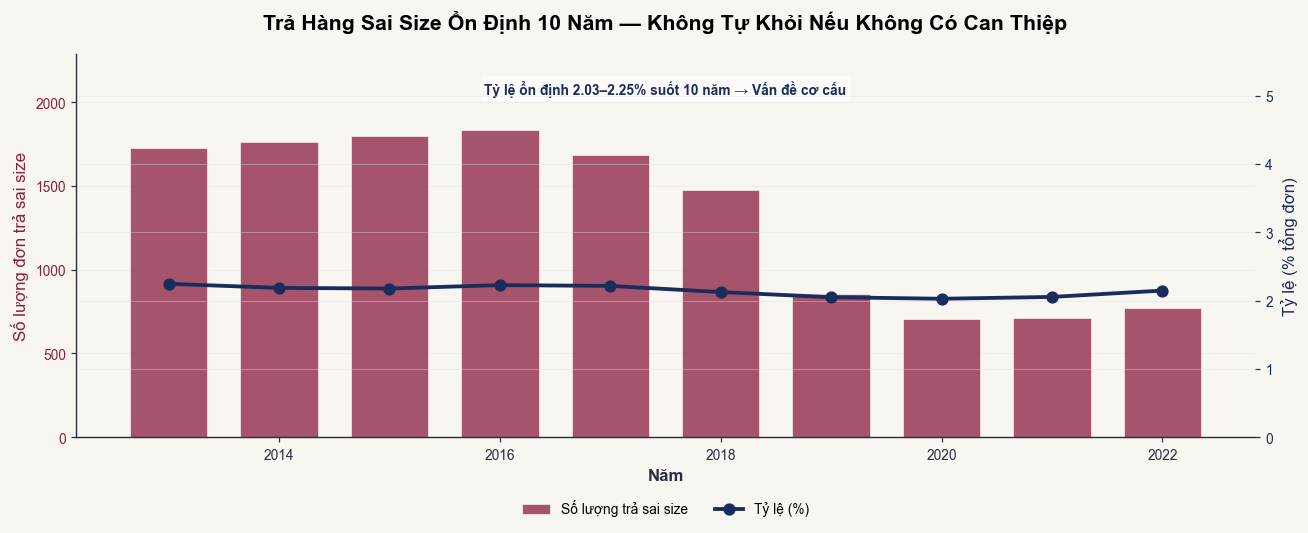

In [15]:
fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

# Bars — trục trái
ax1.bar(trend_df['yr'], trend_df['ws_count'],
        color=SHADOW_PNL_COLORS['leak'], alpha=0.75,
        edgecolor='white', linewidth=0.5, width=0.7,
        label='Số lượng trả sai size')

# Line — trục phải
ax2.plot(trend_df['yr'], trend_df['ws_rate_pct'],
         color=SHADOW_PNL_COLORS['reported'], marker='o',
         linewidth=2.5, markersize=7, label='Tỷ lệ (%)', zorder=5)

rate_min = float(trend_df['ws_rate_pct'].min())
rate_max = float(trend_df['ws_rate_pct'].max())

# Giới hạn cứng — ngăn twinx tự mở rộng, loại bỏ khoảng trắng dư
ax1.set_ylim(0, trend_df['ws_count'].max() * 1.25)
ax2.set_ylim(0, rate_max * 2.5)

ax1.set_ylabel('Số lượng đơn trả sai size', color=SHADOW_PNL_COLORS['leak'])
ax2.set_ylabel('Tỷ lệ (% tổng đơn)', color=SHADOW_PNL_COLORS['reported'])
ax1.tick_params(axis='y', labelcolor=SHADOW_PNL_COLORS['leak'])
ax2.tick_params(axis='y', labelcolor=SHADOW_PNL_COLORS['reported'])

# Annotation dùng axes coordinates — không đẩy ylim
ax1.text(0.5, 0.93,
         f'Tỷ lệ ổn định {rate_min:.2f}–{rate_max:.2f}% suốt 10 năm → Vấn đề cơ cấu',
         transform=ax1.transAxes, ha='center', va='top',
         fontsize=9, color=SHADOW_PNL_COLORS['reported'], fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.75, linewidth=0))

# Legend tổng hợp — bên ngoài, dưới chart
lines1, labs1 = ax1.get_legend_handles_labels()
lines2, labs2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labs1 + labs2,
           loc='upper center', bbox_to_anchor=(0.5, -0.13),
           ncol=2, framealpha=0.9)

finalize_chart(
    ax1,
    title='Trả Hàng Sai Size Ổn Định 10 Năm — Không Tự Khỏi Nếu Không Có Can Thiệp',
    xlabel='Năm',
)
plt.tight_layout()
fig.savefig(CHARTS_DIR / 'act3b_06_sizing_trend.png', bbox_inches='tight')
plt.show()


In [16]:
sizing_total_refund = con.execute("""
    SELECT SUM(refund_amount) FROM returns
    WHERE return_reason IN ('wrong_size', 'not_as_described', 'changed_mind')
""").fetchone()[0]

qw_annual  = layer1_vnd * 0.30 / YEARS   # Quick win: -30% wrong_size
med_annual = sizing_total_refund * 0.50 / YEARS  # Medium: -50% all sizing

ACTIONS = [
    {'label': 'Bảng size\ntương tác',   'effort': 1.5, 'impact': 4.0,
     'savings': qw_annual,        'color': SHADOW_PNL_COLORS['true_net']},
    {'label': 'Điểm tin cậy\nvừa vặn',  'effort': 3.5, 'impact': 7.0,
     'savings': qw_annual * 2.5,  'color': SHADOW_PNL_COLORS['outdoor']},
    {'label': 'Size riêng\ntừng category','effort': 7.0, 'impact': 9.0,
     'savings': med_annual,       'color': SHADOW_PNL_COLORS['upside']},
]
for a in ACTIONS:
    print(f"  {a['label'].replace(chr(10),' ')}: ~{format_vnd(a['savings'])}/năm")


  Bảng size tương tác: ~5 triệu VND/năm
  Điểm tin cậy vừa vặn: ~13 triệu VND/năm
  Size riêng từng category: ~17 triệu VND/năm


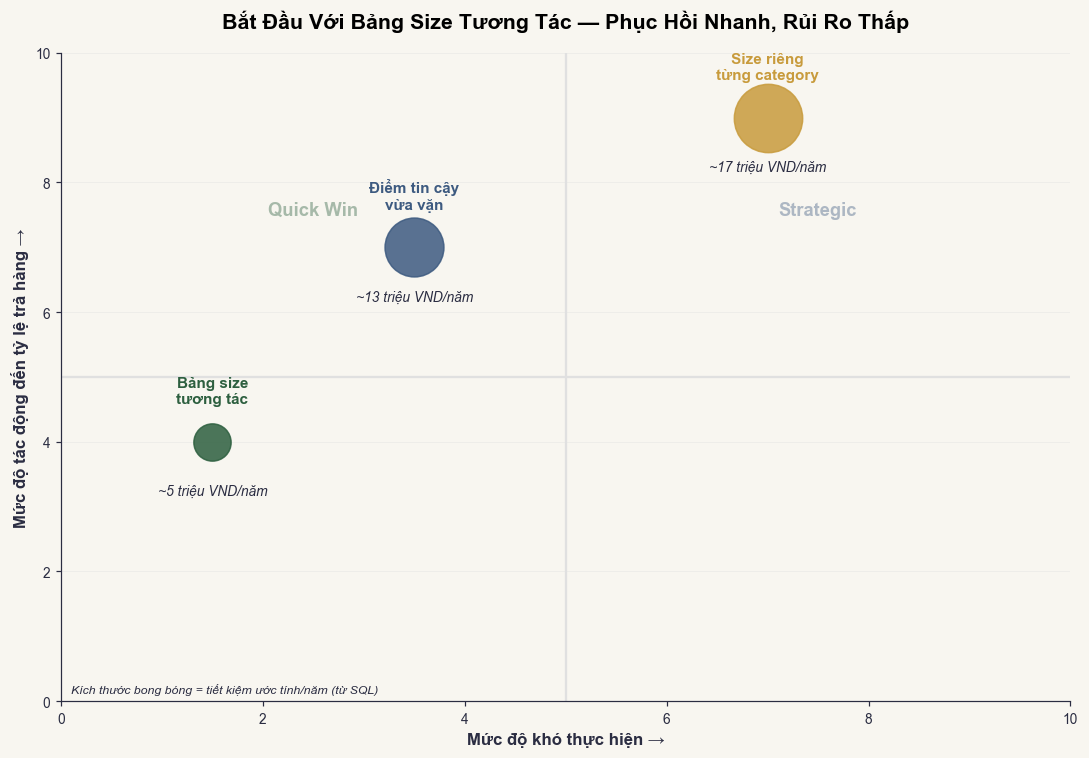

In [17]:
fig, ax = plt.subplots(figsize=(10, 7))
ax.axhline(y=5, color=SHADOW_PNL_COLORS['grid'], linewidth=1.5)
ax.axvline(x=5, color=SHADOW_PNL_COLORS['grid'], linewidth=1.5)
ax.text(2.5, 7.5, 'Quick Win', ha='center', fontsize=12,
        color=SHADOW_PNL_COLORS['true_net'], alpha=0.4, fontweight='bold')
ax.text(7.5, 7.5, 'Strategic', ha='center', fontsize=12,
        color=SHADOW_PNL_COLORS['outdoor'], alpha=0.4, fontweight='bold')

max_sav = max(a['savings'] for a in ACTIONS)
for a in ACTIONS:
    size = max(200, (a['savings'] / max_sav) * 2000)
    ax.scatter(a['effort'], a['impact'], s=size,
               color=a['color'], alpha=0.85, zorder=5)
    ax.text(a['effort'], a['impact'] + 0.55, a['label'],
            ha='center', va='bottom', fontsize=10, fontweight='bold', color=a['color'])
    ax.text(a['effort'], a['impact'] - 0.65,
            f"~{format_vnd(a['savings'])}/năm",
            ha='center', va='top', fontsize=9, style='italic',
            color=SHADOW_PNL_COLORS['text'])

ax.set_xlim(0, 10); ax.set_ylim(0, 10)
finalize_chart(
    ax,
    title='Bắt Đầu Với Bảng Size Tương Tác — Phục Hồi Nhanh, Rủi Ro Thấp',
    xlabel='Mức độ khó thực hiện →',
    ylabel='Mức độ tác động đến tỷ lệ trả hàng →',
)
ax.text(0.01, 0.01, 'Kích thước bong bóng = tiết kiệm ước tính/năm (từ SQL)',
        transform=ax.transAxes, ha='left', va='bottom',
        fontsize=8, style='italic', color=SHADOW_PNL_COLORS['text'])
plt.tight_layout()
fig.savefig(CHARTS_DIR / 'act3b_07_action_matrix.png')
plt.show()


In [18]:
print('=' * 65)
print('TỔNG KẾT — ACT 3B: RETURN BLEEDING')
print('=' * 65)
print(f'\n[Phân phối trả hàng]')
print(f'  Tổng trả hàng 10.5 năm : {total_returns:,}')
print(f'  Liên quan size (3 lý do): {sizing_returns:,} ({sizing_pct:.1f}%)')
print(f'  Wrong_size              : {n_ws_ret:,} ({n_ws_ret/total_returns*100:.1f}%)')
print(f'\n[Kiểm định thống kê — báo cáo trung thực]')
print(f'  Chi-square (size ~ reason): chi²={chi2_val:.2f}, p={p_value:.3f} → {"KHÔNG ý nghĩa" if p_value>=0.05 else "CÓ ý nghĩa"}')
print(f'  Mann-Whitney (LTV erode) : p={mw_p:.4f}  → {"KHÔNG ý nghĩa → Layer 4=0" if mw_p>=0.05 else "CÓ ý nghĩa"}')
print(f'\n[Chi phí (10.5 năm)]')
for label, val, vis in LAYERS:
    tag = '[THẤY]' if vis else '[ẨN] '
    print(f'  {tag} {label.replace(chr(10)," "):25s}: {format_vnd(val)}')
print(f'  {"─"*55}')
print(f'  TỔNG: {format_vnd(total_all)} | hệ số {multiplier:.1f}x (v1 tuyên bố 4x là sai)')
print(f'\n[Cơ hội can thiệp/năm]')
for a in ACTIONS:
    print(f"  {a['label'].replace(chr(10),' ')}: ~{format_vnd(a['savings'])}")
print(f'\n[Biểu đồ đã lưu tại outputs_round1/charts/]')
for f in sorted(CHARTS_DIR.glob('act3b_*.png')):
    print(f'  {f.name}')
print(f'\n[Audit trail: outputs_round1/shadow_pnl_audit.csv]')


TỔNG KẾT — ACT 3B: RETURN BLEEDING

[Phân phối trả hàng]
  Tổng trả hàng 10.5 năm : 39,939
  Liên quan size (3 lý do): 27,933 (69.9%)
  Wrong_size              : 13,967 (35.0%)

[Kiểm định thống kê — báo cáo trung thực]
  Chi-square (size ~ reason): chi²=9.89, p=0.625 → KHÔNG ý nghĩa
  Mann-Whitney (LTV erode) : p=0.4188  → KHÔNG ý nghĩa → Layer 4=0

[Chi phí (10.5 năm)]
  [THẤY] Hoàn tiền trực tiếp      : 177 triệu VND
  [THẤY] Logistics ngược          : 207.9 nghìn VND
  [ẨN]  Hàng tồn dư              : 12 triệu VND
  [ẨN]  Mất LTV                  : 0 VND
  [ẨN]  Thiệt hại đánh giá       : 5 triệu VND
  ───────────────────────────────────────────────────────
  TỔNG: 194 triệu VND | hệ số 1.1x (v1 tuyên bố 4x là sai)

[Cơ hội can thiệp/năm]
  Bảng size tương tác: ~5 triệu VND
  Điểm tin cậy vừa vặn: ~13 triệu VND
  Size riêng từng category: ~17 triệu VND

[Biểu đồ đã lưu tại outputs_round1/charts/]
  act3b_01_return_reasons.png
  act3b_02_size_by_reason.png
  act3b_03_days_to_return.